# Weighted Wasserstein DRO Logistic Regression — Experiments

This notebook implements and evaluates **Weighted (Anisotropic) Wasserstein Distributionally Robust Logistic Regression**.
We compare four models:

| Model | Regularization | Description |
|-------|---------------|-------------|
| Standard LR | None | Unregularized logistic regression |
| Ridge LR | $\alpha \|\theta\|_2^2$ | L2-regularized logistic regression |
| DRO LR | $\varepsilon \|\theta\|_\infty$ | Wasserstein DRO, uniform ground metric |
| Weighted DRO LR | $\varepsilon \|D^{-1}\theta\|_\infty$ | Wasserstein DRO, anisotropic ground metric |

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, fetch_openml
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid', font_scale=1.2)
%matplotlib inline

---
## Section 1: Model Implementations (CVXPY)

All four models are formulated as convex programs and solved via CVXPY.

**Key dual result:** Under an L1 Wasserstein ball with diagonal ground-metric matrix
$D = \mathrm{diag}(d_1, \dots, d_p)$, the primal min-max DRO problem

$$\min_\theta \;\max_{Q:\; W_c(Q,\hat P_n)\le\varepsilon}\; \mathbb{E}_Q\!\bigl[\ell(\theta;\xi)\bigr]$$

is equivalent (via strong duality) to the tractable convex program

$$\min_\theta \; \frac{1}{n}\sum_{i=1}^{n} \log\!\bigl(1 + e^{-y_i \mathbf{x}_i^\top\theta}\bigr) \;+\; \varepsilon\,\bigl\|D^{-1}\theta\bigr\|_\infty$$

Features with small $d_j$ (low trust) are penalised heavily, encouraging the model to ignore them.

In [2]:
def logistic_loss_expr(theta, X, y):
    """CVXPY expression for mean logistic loss."""
    n = X.shape[0]
    return cp.sum(cp.logistic(cp.multiply(-y, X @ theta))) / n


def fit_standard_lr(X, y):
    """Standard (unregularized) logistic regression."""
    p = X.shape[1]
    theta = cp.Variable(p)
    prob = cp.Problem(cp.Minimize(logistic_loss_expr(theta, X, y)))
    t0 = time.time()
    prob.solve(solver=cp.SCS, max_iters=10000, verbose=False)
    return theta.value, time.time() - t0


def fit_ridge_lr(X, y, alpha=0.1):
    """L2-regularized logistic regression."""
    p = X.shape[1]
    theta = cp.Variable(p)
    loss = logistic_loss_expr(theta, X, y) + alpha * cp.sum_squares(theta)
    prob = cp.Problem(cp.Minimize(loss))
    t0 = time.time()
    prob.solve(solver=cp.SCS, max_iters=10000, verbose=False)
    return theta.value, time.time() - t0


def fit_dro_lr(X, y, eps=0.1):
    """Unweighted Wasserstein DRO: logistic loss + eps * ||theta||_inf."""
    p = X.shape[1]
    theta = cp.Variable(p)
    loss = logistic_loss_expr(theta, X, y) + eps * cp.norm(theta, "inf")
    prob = cp.Problem(cp.Minimize(loss))
    t0 = time.time()
    prob.solve(solver=cp.SCS, max_iters=10000, verbose=False)
    return theta.value, time.time() - t0


def fit_weighted_dro_lr(X, y, d, eps=0.1):
    """Weighted Wasserstein DRO: logistic loss + eps * ||D^{-1} theta||_inf."""
    p = X.shape[1]
    theta = cp.Variable(p)
    d_inv = 1.0 / np.array(d, dtype=float)
    loss = logistic_loss_expr(theta, X, y) + eps * cp.norm(cp.multiply(d_inv, theta), "inf")
    prob = cp.Problem(cp.Minimize(loss))
    t0 = time.time()
    prob.solve(solver=cp.SCS, max_iters=10000, verbose=False)
    return theta.value, time.time() - t0


def predict(theta, X):
    if theta is None:
        return None
    return np.sign(X @ theta)


def accuracy(theta, X, y):
    if theta is None:
        return np.nan
    return np.mean(predict(theta, X) == y)


MODEL_NAMES = ['Standard LR', 'Ridge LR', 'DRO LR', 'Weighted DRO LR']
COLORS  = {'Standard LR': 'C0', 'Ridge LR': 'C1', 'DRO LR': 'C2', 'Weighted DRO LR': 'C3'}
MARKERS = {'Standard LR': 'o',  'Ridge LR': 's',  'DRO LR': '^',  'Weighted DRO LR': 'D'}

---
## Section 2: Synthetic Experiment — Test-Time Feature Corruption

**Goal:** Show that Weighted DRO maintains accuracy when auxiliary features become noisy at test time.

All 10 features carry signal during training, but features 2–9 are corrupted at test time
to simulate deployment-time distribution shift.

| Parameter | Value |
|-----------|-------|
| Total features $p$ | 10 |
| True model | $\theta^* = [3, 3, 0.5, \dots, 0.5]$ |
| Signal features | $x_0, x_1$ (strong signal, high trust) |
| Auxiliary features | $x_2, \dots, x_9$ (weak signal, low trust) |
| Training samples | 300 |
| Test samples | 500 |
| Weight vector $d$ | $[3, 3, 0.1, \dots, 0.1]$ |
| Test-time corruption | Additive $\mathcal{N}(0, \sigma^2)$ on $x_2, \dots, x_9$ |

In [3]:
THETA_TRUE = np.zeros(10)
THETA_TRUE[:2] = 3.0
THETA_TRUE[2:] = 0.5

AUX_IDX = list(range(2, 10))

def generate_synthetic_data(n_train=300, n_test=500, p=10, seed=42):
    """Generate clean training and test data (all features informative)."""
    rng = np.random.RandomState(seed)

    X_train = rng.randn(n_train, p)
    X_test  = rng.randn(n_test, p)

    y_train = np.sign(X_train @ THETA_TRUE + 1.5 * rng.randn(n_train))
    y_test  = np.sign(X_test  @ THETA_TRUE + 1.5 * rng.randn(n_test))
    y_train[y_train == 0] = 1
    y_test[y_test == 0]   = 1

    return X_train, y_train, X_test, y_test


def corrupt_features(X, indices, sigma, rng):
    """Add Gaussian noise to selected features."""
    X_noisy = X.copy()
    X_noisy[:, indices] += sigma * rng.randn(X.shape[0], len(indices))
    return X_noisy


d_synth = np.ones(10)
d_synth[:2] = 3.0
d_synth[2:] = 0.1

print('Data generation ready.')
print(f'theta* = {THETA_TRUE}')
print(f'd     = {d_synth}')

Data generation ready.
theta* = [3.  3.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
d     = [3.  3.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


In [4]:
sigma_values = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]
n_seeds = 10
eps_synth   = 0.1
alpha_synth = 0.01

results_synth = {name: np.zeros((len(sigma_values), n_seeds)) for name in MODEL_NAMES}
timing_synth  = {name: [] for name in MODEL_NAMES}

for s in range(n_seeds):
    X_tr, y_tr, X_te, y_te = generate_synthetic_data(seed=s * 100)

    th_std,   t1 = fit_standard_lr(X_tr, y_tr)
    th_ridge, t2 = fit_ridge_lr(X_tr, y_tr, alpha=alpha_synth)
    th_dro,   t3 = fit_dro_lr(X_tr, y_tr, eps=eps_synth)
    th_wdro,  t4 = fit_weighted_dro_lr(X_tr, y_tr, d=d_synth, eps=eps_synth)

    thetas = [th_std, th_ridge, th_dro, th_wdro]
    times  = [t1, t2, t3, t4]

    for i, sigma in enumerate(sigma_values):
        rng_s = np.random.RandomState(s * 1000 + i)
        X_te_noisy = corrupt_features(X_te, AUX_IDX, sigma, rng_s)

        for name, th, t in zip(MODEL_NAMES, thetas, times):
            results_synth[name][i, s] = accuracy(th, X_te_noisy, y_te)
            timing_synth[name].append(t)

    print(f'seed {s} complete')

print('Corruption sweep done.')

seed 0 complete
seed 1 complete
seed 2 complete
seed 3 complete
seed 4 complete
seed 5 complete
seed 6 complete
seed 7 complete
seed 8 complete
seed 9 complete
Corruption sweep done.


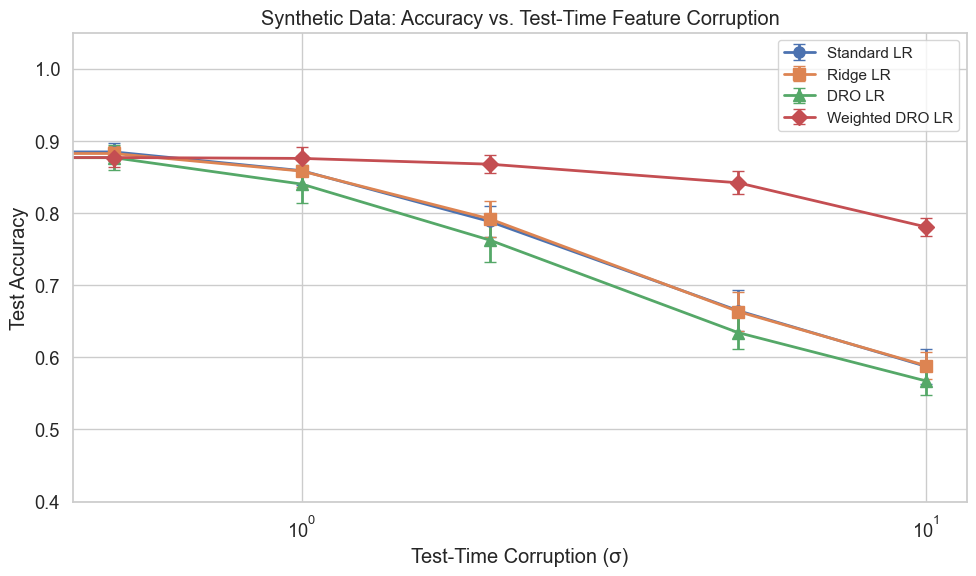

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for name in MODEL_NAMES:
    mean = np.nanmean(results_synth[name], axis=1)
    std  = np.nanstd(results_synth[name], axis=1)
    ax.errorbar(sigma_values, mean, yerr=std, label=name,
                marker=MARKERS[name], color=COLORS[name],
                capsize=4, linewidth=2, markersize=8)

ax.set_xlabel('Test-Time Corruption (\u03c3)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Synthetic Data: Accuracy vs. Test-Time Feature Corruption')
ax.legend(fontsize=11)
ax.set_xscale('log')
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

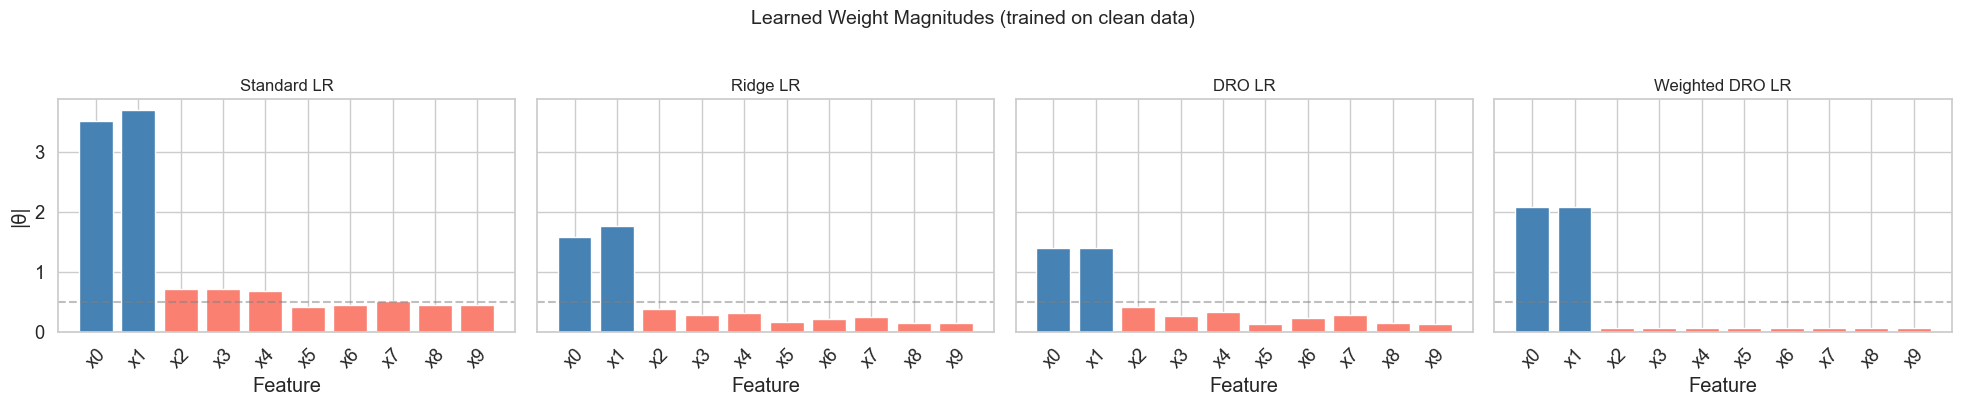

True weights: [3.  3.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Standard LR         : [3.514 3.691 0.709 0.71  0.684 0.417 0.442 0.519 0.444 0.45 ]
Ridge LR            : [1.572 1.762 0.38  0.272 0.314 0.157 0.21  0.253 0.148 0.15 ]
DRO LR              : [1.388 1.388 0.408 0.265 0.324 0.13  0.223 0.285 0.146 0.125]
Weighted DRO LR     : [2.081 2.081 0.069 0.069 0.069 0.069 0.069 0.069 0.069 0.069]


In [6]:
X_tr, y_tr, X_te, y_te = generate_synthetic_data(seed=42)

th_std,   _ = fit_standard_lr(X_tr, y_tr)
th_ridge, _ = fit_ridge_lr(X_tr, y_tr, alpha=alpha_synth)
th_dro,   _ = fit_dro_lr(X_tr, y_tr, eps=eps_synth)
th_wdro,  _ = fit_weighted_dro_lr(X_tr, y_tr, d=d_synth, eps=eps_synth)

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
feat_labels = [f'x{i}' for i in range(10)]
bar_colors  = ['steelblue'] * 2 + ['salmon'] * 8

for ax, name, theta in zip(axes, MODEL_NAMES,
                            [th_std, th_ridge, th_dro, th_wdro]):
    vals = np.abs(theta) if theta is not None else np.zeros(10)
    ax.bar(feat_labels, vals, color=bar_colors)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Feature')
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('|\u03b8|')
fig.suptitle('Learned Weight Magnitudes (trained on clean data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('True weights:', THETA_TRUE)
for name, th in zip(MODEL_NAMES, [th_std, th_ridge, th_dro, th_wdro]):
    if th is not None:
        print(f'{name:20s}: {np.round(th, 3)}')

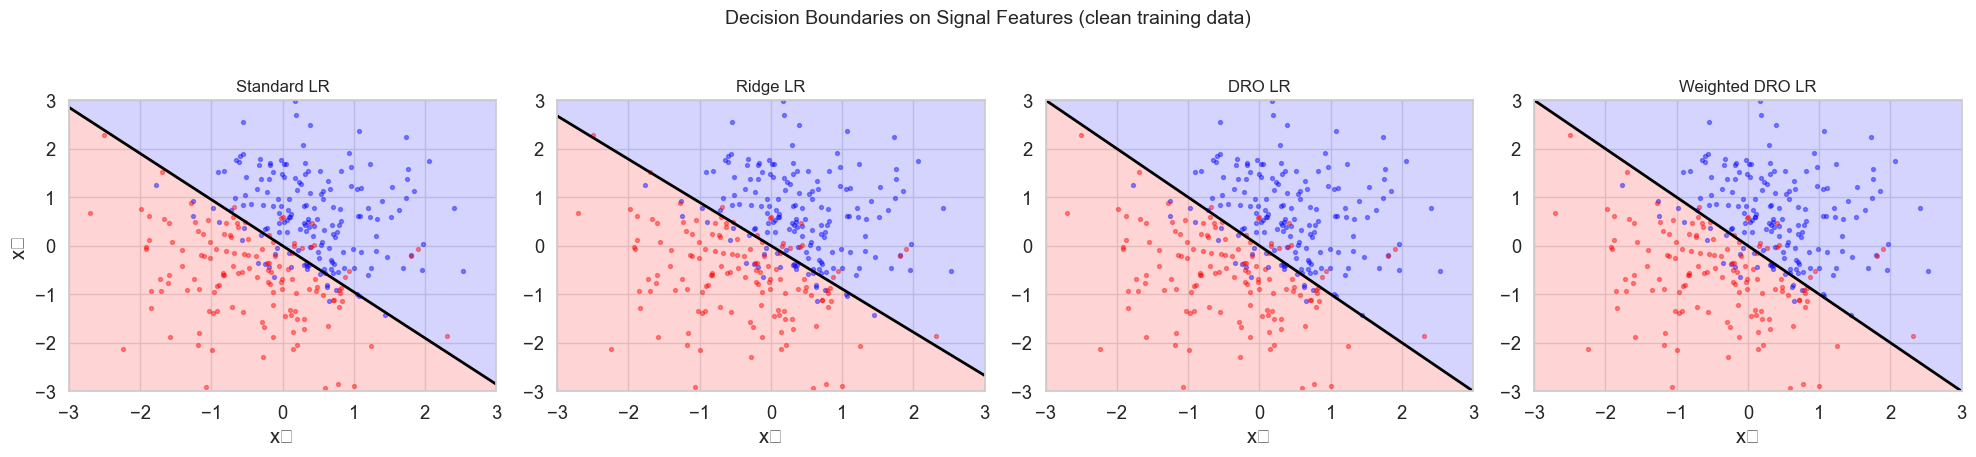

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid_2d   = np.c_[xx.ravel(), yy.ravel()]
grid_full = np.hstack([grid_2d, np.zeros((grid_2d.shape[0], 8))])

for ax, name, theta in zip(axes, MODEL_NAMES,
                            [th_std, th_ridge, th_dro, th_wdro]):
    if theta is None:
        ax.set_title(f'{name}\n(solver failed)')
        continue
    zz = (grid_full @ theta).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-1e10, 0, 1e10],
                colors=['#FFAAAA', '#AAAAFF'], alpha=0.5)
    ax.contour(xx, yy, zz, levels=[0], colors='black', linewidths=2)

    mask_pos = y_tr == 1
    ax.scatter(X_tr[mask_pos, 0],  X_tr[mask_pos, 1],
               c='blue', s=8, alpha=0.4, label='+1')
    ax.scatter(X_tr[~mask_pos, 0], X_tr[~mask_pos, 1],
               c='red',  s=8, alpha=0.4, label='-1')

    ax.set_title(name, fontsize=12)
    ax.set_xlabel('x\u2080')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

axes[0].set_ylabel('x\u2081')
fig.suptitle('Decision Boundaries on Signal Features (clean training data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Hyperparameter Sensitivity: Robustness Radius $\varepsilon$

Sweep $\varepsilon$ with fixed $\sigma = 5$ to study how the robustness budget interacts with
the anisotropic weight vector.

ε = 0.010 complete
ε = 0.050 complete
ε = 0.100 complete
ε = 0.500 complete
ε = 1.000 complete
ε = 5.000 complete


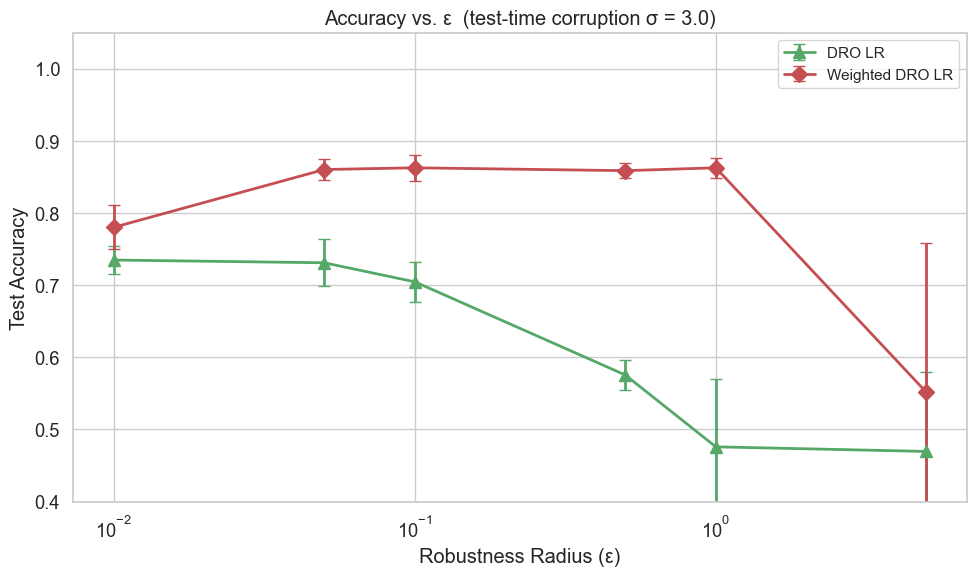

In [8]:
eps_values    = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
n_seeds_eps   = 10
sigma_corrupt = 3.0

eps_results = {name: np.zeros((len(eps_values), n_seeds_eps))
               for name in ['DRO LR', 'Weighted DRO LR']}

for i, e in enumerate(eps_values):
    for s in range(n_seeds_eps):
        X_tr, y_tr, X_te, y_te = generate_synthetic_data(seed=s * 100)
        rng_e = np.random.RandomState(s * 1000 + i)
        X_te_noisy = corrupt_features(X_te, AUX_IDX, sigma_corrupt, rng_e)

        th_dro,  _ = fit_dro_lr(X_tr, y_tr, eps=e)
        th_wdro, _ = fit_weighted_dro_lr(X_tr, y_tr, d=d_synth, eps=e)

        eps_results['DRO LR'][i, s]          = accuracy(th_dro,  X_te_noisy, y_te)
        eps_results['Weighted DRO LR'][i, s] = accuracy(th_wdro, X_te_noisy, y_te)

    print(f'\u03b5 = {e:.3f} complete')

fig, ax = plt.subplots(figsize=(10, 6))
for name in ['DRO LR', 'Weighted DRO LR']:
    mean = np.nanmean(eps_results[name], axis=1)
    std  = np.nanstd(eps_results[name], axis=1)
    ax.errorbar(eps_values, mean, yerr=std, label=name,
                marker=MARKERS[name], color=COLORS[name],
                capsize=4, linewidth=2, markersize=8)

ax.set_xlabel('Robustness Radius (\u03b5)')
ax.set_ylabel('Test Accuracy')
ax.set_title(f'Accuracy vs. \u03b5  (test-time corruption \u03c3 = {sigma_corrupt})')
ax.legend(fontsize=11)
ax.set_xscale('log')
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

---
## Section 3: Real-World Experiment 1 — UCI Adult Income

**Goal:** Demonstrate robustness on a real dataset with naturally heterogeneous features.

| Feature | Trust | $d_j$ |
|---------|-------|-------|
| age | High | 1.0 |
| fnlwgt | Low | 0.1 |
| education-num | High | 1.0 |
| capital-gain | Low | 0.1 |
| capital-loss | Low | 0.1 |
| hours-per-week | High | 1.0 |

Distribution shift is simulated by corrupting the low-trust features at test time.

In [9]:
print('Loading UCI Adult dataset...')
adult = fetch_openml('adult', version=2, as_frame=True, parser='auto')
df_adult = adult.frame

target_col = [c for c in df_adult.columns if c in ('income', 'class', 'target')][-1]
y_adult_raw = (df_adult[target_col].astype(str)
               .apply(lambda x: 1 if '>50K' in x else -1).values)

num_cols_adult = ['age', 'fnlwgt', 'education-num',
                  'capital-gain', 'capital-loss', 'hours-per-week']

df_num = df_adult[num_cols_adult].apply(pd.to_numeric, errors='coerce')
valid = df_num.notna().all(axis=1)
X_adult_raw = df_num[valid].values.astype(float)
y_adult_all = y_adult_raw[valid.values]

scaler_adult = StandardScaler()
X_adult_scaled = scaler_adult.fit_transform(X_adult_raw)

rng_adult = np.random.RandomState(42)
n_sub = min(3000, len(X_adult_scaled))
idx = rng_adult.choice(len(X_adult_scaled), n_sub, replace=False)

X_adult_train, X_adult_test, y_adult_train, y_adult_test = train_test_split(
    X_adult_scaled[idx], y_adult_all[idx],
    test_size=0.2, random_state=42)

print(f'Training: {X_adult_train.shape}, Test: {X_adult_test.shape}')
print(f'Class balance (train): {np.mean(y_adult_train == 1):.2%} positive')

Loading UCI Adult dataset...
Training: (2400, 6), Test: (600, 6)
Class balance (train): 24.04% positive


In [10]:
d_adult = np.array([1.0, 0.1, 1.0, 0.1, 0.1, 1.0])
noisy_idx_adult = [1, 3, 4]

alpha_adult = 0.01
eps_adult   = 0.1

print('Training models...')
th_adult_std,   t1 = fit_standard_lr(X_adult_train, y_adult_train)
th_adult_ridge, t2 = fit_ridge_lr(X_adult_train, y_adult_train, alpha=alpha_adult)
th_adult_dro,   t3 = fit_dro_lr(X_adult_train, y_adult_train, eps=eps_adult)
th_adult_wdro,  t4 = fit_weighted_dro_lr(X_adult_train, y_adult_train,
                                          d=d_adult, eps=eps_adult)

thetas_adult = [th_adult_std, th_adult_ridge, th_adult_dro, th_adult_wdro]
times_adult  = [t1, t2, t3, t4]

print('Clean test accuracy:')
for name, th, t in zip(MODEL_NAMES, thetas_adult, times_adult):
    print(f'  {name:20s}: {accuracy(th, X_adult_test, y_adult_test):.4f}  ({t:.2f}s)')

corruption_levels = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
n_seeds_adult = 10
adult_shift = {name: np.zeros((len(corruption_levels), n_seeds_adult))
               for name in MODEL_NAMES}

for i, noise_mag in enumerate(corruption_levels):
    for s in range(n_seeds_adult):
        rng_a = np.random.RandomState(s * 100 + i)
        X_te_corrupt = X_adult_test.copy()
        X_te_corrupt[:, noisy_idx_adult] += noise_mag * rng_a.randn(
            X_adult_test.shape[0], len(noisy_idx_adult))

        for name, th in zip(MODEL_NAMES, thetas_adult):
            adult_shift[name][i, s] = accuracy(th, X_te_corrupt, y_adult_test)

print('Distribution shift experiment complete.')

Training models...
Clean test accuracy:
  Standard LR         : 0.8000  (0.59s)
  Ridge LR            : 0.7183  (0.31s)
  DRO LR              : 0.6967  (0.52s)
  Weighted DRO LR     : 0.6817  (0.71s)
Distribution shift experiment complete.


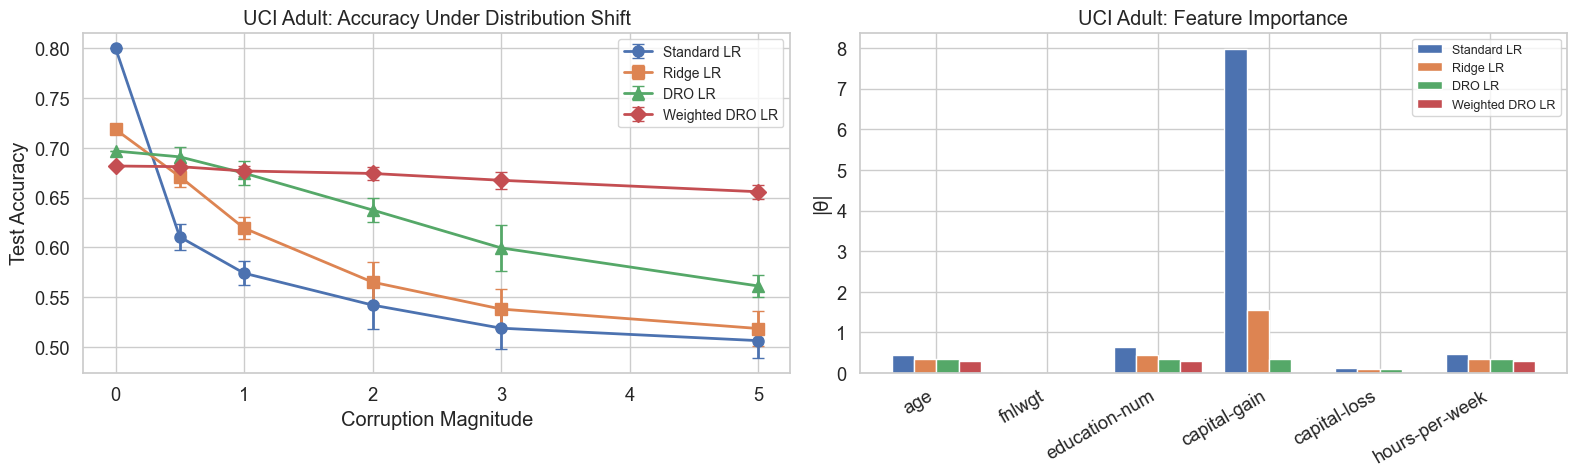

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for name in MODEL_NAMES:
    mean = np.nanmean(adult_shift[name], axis=1)
    std  = np.nanstd(adult_shift[name], axis=1)
    ax.errorbar(corruption_levels, mean, yerr=std, label=name,
                marker=MARKERS[name], color=COLORS[name],
                capsize=4, linewidth=2, markersize=8)
ax.set_xlabel('Corruption Magnitude')
ax.set_ylabel('Test Accuracy')
ax.set_title('UCI Adult: Accuracy Under Distribution Shift')
ax.legend(fontsize=10)

ax = axes[1]
x_pos = np.arange(len(num_cols_adult))
width = 0.2
for j, (name, th) in enumerate(zip(MODEL_NAMES, thetas_adult)):
    vals = np.abs(th) if th is not None else np.zeros(len(num_cols_adult))
    ax.bar(x_pos + j * width, vals, width, label=name, color=COLORS[name])
ax.set_xticks(x_pos + 1.5 * width)
ax.set_xticklabels(num_cols_adult, rotation=30, ha='right')
ax.set_ylabel('|\u03b8|')
ax.set_title('UCI Adult: Feature Importance')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 4: Real-World Experiment 2 — Wisconsin Breast Cancer

**Goal:** Medical diagnosis setting where feature reliability varies by measurement type.

The dataset has 30 features = 10 base measurements $\times$ 3 statistics:

| Group | Features | Trust | $d_j$ |
|-------|----------|-------|-------|
| Mean  | 0–9   | High   | 1.0 |
| SE    | 10–19 | Low    | 0.2 |
| Worst | 20–29 | Medium | 0.5 |

Noise is injected into the **SE** features at test time to simulate measurement variability.

In [12]:
cancer = load_breast_cancer()
X_cancer_raw = cancer.data
y_cancer_all = 2 * cancer.target - 1
feature_names_cancer = list(cancer.feature_names)

scaler_cancer = StandardScaler()
X_cancer_scaled = scaler_cancer.fit_transform(X_cancer_raw)

X_cancer_train, X_cancer_test, y_cancer_train, y_cancer_test = train_test_split(
    X_cancer_scaled, y_cancer_all,
    test_size=0.2, random_state=42, stratify=y_cancer_all)

mean_idx  = list(range(0, 10))
se_idx    = list(range(10, 20))
worst_idx = list(range(20, 30))

d_cancer = np.ones(30)
d_cancer[mean_idx]  = 1.0
d_cancer[worst_idx] = 0.5
d_cancer[se_idx]    = 0.2

print(f'Training: {X_cancer_train.shape}, Test: {X_cancer_test.shape}')
print(f'Feature groups: mean (0-9), SE (10-19), worst (20-29)')

Training: (455, 30), Test: (114, 30)
Feature groups: mean (0-9), SE (10-19), worst (20-29)


In [13]:
alpha_cancer = 0.01
eps_cancer   = 0.1

print('Training models...')
th_cancer_std,   t1 = fit_standard_lr(X_cancer_train, y_cancer_train)
th_cancer_ridge, t2 = fit_ridge_lr(X_cancer_train, y_cancer_train, alpha=alpha_cancer)
th_cancer_dro,   t3 = fit_dro_lr(X_cancer_train, y_cancer_train, eps=eps_cancer)
th_cancer_wdro,  t4 = fit_weighted_dro_lr(X_cancer_train, y_cancer_train,
                                           d=d_cancer, eps=eps_cancer)

thetas_cancer = [th_cancer_std, th_cancer_ridge, th_cancer_dro, th_cancer_wdro]
times_cancer  = [t1, t2, t3, t4]

print('Clean test accuracy:')
for name, th, t in zip(MODEL_NAMES, thetas_cancer, times_cancer):
    print(f'  {name:20s}: {accuracy(th, X_cancer_test, y_cancer_test):.4f}  ({t:.2f}s)')

noise_levels_cancer = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
n_seeds_cancer = 10
cancer_shift = {name: np.zeros((len(noise_levels_cancer), n_seeds_cancer))
                for name in MODEL_NAMES}

for i, noise_mag in enumerate(noise_levels_cancer):
    for s in range(n_seeds_cancer):
        rng_c = np.random.RandomState(s * 100 + i)
        X_te_noisy = X_cancer_test.copy()
        X_te_noisy[:, se_idx] += noise_mag * rng_c.randn(
            X_cancer_test.shape[0], len(se_idx))

        for name, th in zip(MODEL_NAMES, thetas_cancer):
            cancer_shift[name][i, s] = accuracy(th, X_te_noisy, y_cancer_test)

print('Noise injection experiment complete.')

Training models...
Clean test accuracy:
  Standard LR         : 0.9123  (0.76s)
  Ridge LR            : 0.9649  (0.09s)
  DRO LR              : 0.9649  (0.11s)
  Weighted DRO LR     : 0.9386  (0.09s)
Noise injection experiment complete.


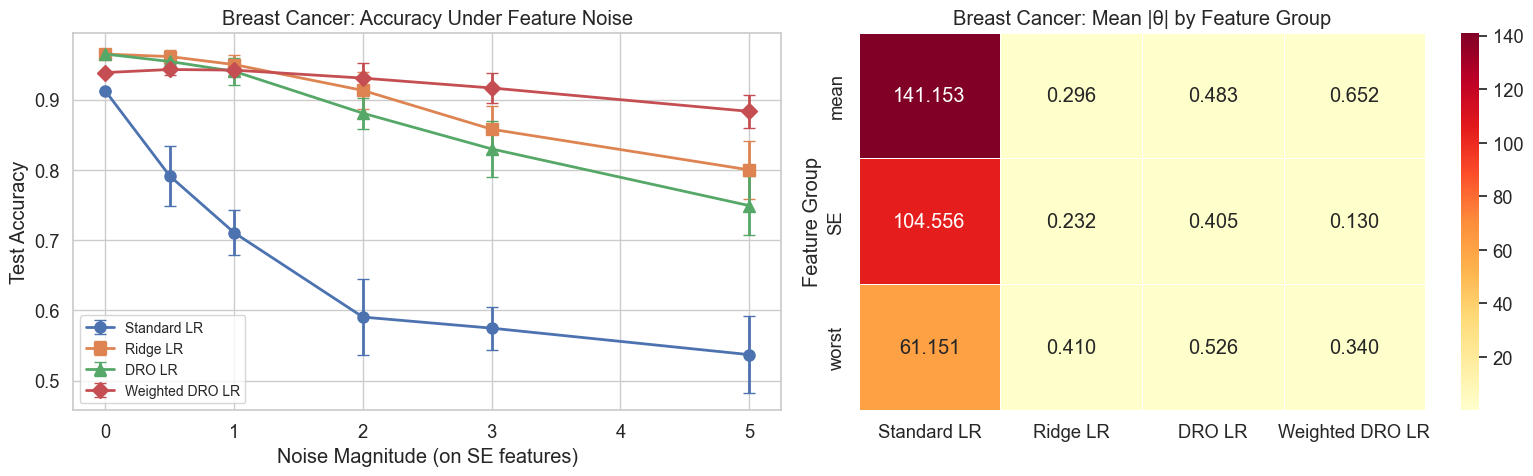

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for name in MODEL_NAMES:
    mean = np.nanmean(cancer_shift[name], axis=1)
    std  = np.nanstd(cancer_shift[name], axis=1)
    ax.errorbar(noise_levels_cancer, mean, yerr=std, label=name,
                marker=MARKERS[name], color=COLORS[name],
                capsize=4, linewidth=2, markersize=8)
ax.set_xlabel('Noise Magnitude (on SE features)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Breast Cancer: Accuracy Under Feature Noise')
ax.legend(fontsize=10)

ax = axes[1]
group_labels  = ['mean', 'SE', 'worst']
group_indices = [mean_idx, se_idx, worst_idx]
weight_by_group = {}
for name, th in zip(MODEL_NAMES, thetas_cancer):
    if th is not None:
        weight_by_group[name] = [np.mean(np.abs(th[gi])) for gi in group_indices]
    else:
        weight_by_group[name] = [0.0, 0.0, 0.0]

heatmap_df = pd.DataFrame(weight_by_group, index=group_labels)
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, linewidths=0.5)
ax.set_title('Breast Cancer: Mean |\u03b8| by Feature Group')
ax.set_ylabel('Feature Group')

plt.tight_layout()
plt.show()

---
## Section 5: Summary and Analysis

In [15]:
rows = []

for name in MODEL_NAMES:
    clean = np.nanmean(results_synth[name][0, :])
    noisy = np.nanmean(results_synth[name][-1, :])
    rows.append({'Experiment': 'Synthetic', 'Model': name,
                 'Clean Acc': f'{clean:.4f}', 'Noisy Acc': f'{noisy:.4f}',
                 'Drop': f'{clean - noisy:.4f}'})

for name in MODEL_NAMES:
    clean = np.nanmean(adult_shift[name][0, :])
    noisy = np.nanmean(adult_shift[name][-1, :])
    rows.append({'Experiment': 'UCI Adult', 'Model': name,
                 'Clean Acc': f'{clean:.4f}', 'Noisy Acc': f'{noisy:.4f}',
                 'Drop': f'{clean - noisy:.4f}'})

for name in MODEL_NAMES:
    clean = np.nanmean(cancer_shift[name][0, :])
    noisy = np.nanmean(cancer_shift[name][-1, :])
    rows.append({'Experiment': 'Breast Cancer', 'Model': name,
                 'Clean Acc': f'{clean:.4f}', 'Noisy Acc': f'{noisy:.4f}',
                 'Drop': f'{clean - noisy:.4f}'})

summary_df = pd.DataFrame(rows)
print('=' * 70)
print('RESULTS SUMMARY')
print('=' * 70)
print(summary_df.to_string(index=False))
print()

print('=' * 70)
print('AVERAGE SOLVE TIME — Synthetic (n=300, p=10)')
print('=' * 70)
for name in MODEL_NAMES:
    print(f'  {name:20s}: {np.mean(timing_synth[name]):.4f} s')

RESULTS SUMMARY
   Experiment           Model Clean Acc Noisy Acc   Drop
    Synthetic     Standard LR    0.8970    0.5874 0.3096
    Synthetic        Ridge LR    0.8948    0.5884 0.3064
    Synthetic          DRO LR    0.8894    0.5672 0.3222
    Synthetic Weighted DRO LR    0.8794    0.7806 0.0988
    UCI Adult     Standard LR    0.8000    0.5065 0.2935
    UCI Adult        Ridge LR    0.7183    0.5187 0.1997
    UCI Adult          DRO LR    0.6967    0.5613 0.1353
    UCI Adult Weighted DRO LR    0.6817    0.6558 0.0258
Breast Cancer     Standard LR    0.9123    0.5368 0.3754
Breast Cancer        Ridge LR    0.9649    0.8000 0.1649
Breast Cancer          DRO LR    0.9649    0.7491 0.2158
Breast Cancer Weighted DRO LR    0.9386    0.8833 0.0553

AVERAGE SOLVE TIME — Synthetic (n=300, p=10)
  Standard LR         : 0.1056 s
  Ridge LR            : 0.0392 s
  DRO LR              : 0.0522 s
  Weighted DRO LR     : 0.0555 s
